# Tercile Labeling Schematic
Academic illustration of the rolling-window tercile labeling used in `utils/preprocessing.py`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})

In [2]:
# ── Synthetic data: ~40 years of weekly rainfall anomalies at one grid point ──
rng = np.random.default_rng(42)
n_years = 40
weeks = np.arange(1, 53)
T = n_years * 52  # total time steps

# seasonal cycle + noise
week_cycle = np.tile(weeks, n_years)
raw = 5 * np.sin(2 * np.pi * week_cycle / 52) + rng.normal(0, 2, T)

# ISO week numbers and year index
year_idx = np.repeat(np.arange(n_years), 52)

# ── Rolling-window tercile edges (window=1 → weeks w-1, w, w+1) ──
window = 1
edges_lower = np.full(52, np.nan)
edges_upper = np.full(52, np.nan)

for w in weeks:
    week_window = [(w + i - 1) % 52 + 1 for i in range(-window, window + 1)]
    mask = np.isin(week_cycle, week_window)
    vals = raw[mask]
    edges_lower[w - 1] = np.quantile(vals, 1 / 3)
    edges_upper[w - 1] = np.quantile(vals, 2 / 3)

# ── Assign labels ──
labels = np.full(T, np.nan)
for t in range(T):
    w = week_cycle[t] - 1          # 0-indexed
    if raw[t] < edges_lower[w]:
        labels[t] = 0              # Below-normal
    elif raw[t] > edges_upper[w]:
        labels[t] = 2              # Above-normal
    else:
        labels[t] = 1              # Near-normal

print("Label counts:", {0: int((labels==0).sum()), 1: int((labels==1).sum()), 2: int((labels==2).sum())})

Label counts: {0: 695, 1: 691, 2: 694}


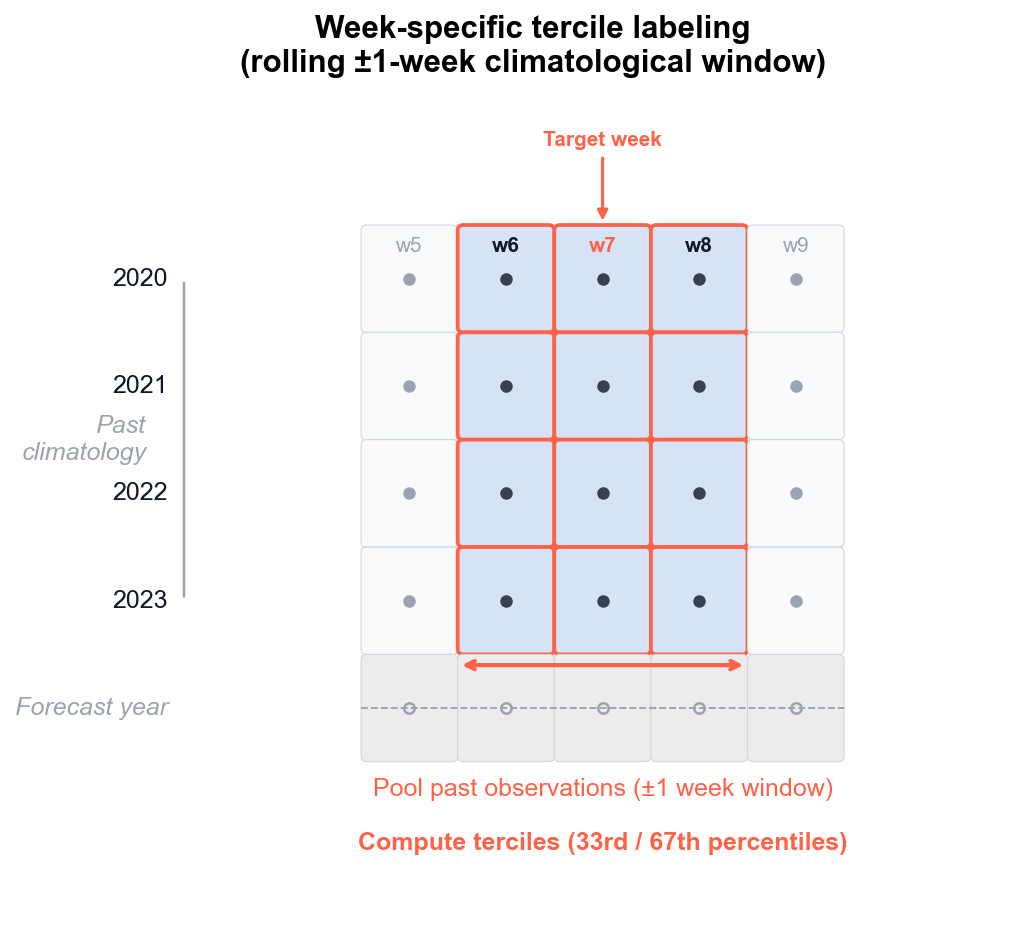

In [32]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"

# ── setup ─────────────────────────────────────────────────────────
n_years    = 4
focus_week = 7
win_weeks  = [focus_week - 1, focus_week, focus_week + 1]
weeks_show = list(range(5, 10))  # tighter window

C = {
    "pool":  "#D6E3F7",
    "other": "#F9FAFB",
    "fc":    "#ECECEC",
    "bord":  "tomato",
    "grid":  "#D1D5DB",
    "txt":   "#111827",
    "dim":   "#9CA3AF",
}

cw, ch = 0.9, 1.0
row_label_x = -1.8
bracket_gap = 0.5

fig, ax = plt.subplots(figsize=(7, 7.5))
ax.set_aspect("equal")
ax.axis("off")

all_rows = list(range(n_years)) + ["fc"]

# ── cells ─────────────────────────────────────────────────────────
for row, yr in enumerate(all_rows):
    is_fc = (yr == "fc")
    for col, w in enumerate(weeks_show):
        x = col * cw
        y = -row * ch
        in_win = (w in win_weeks) and not is_fc

        fc = C["pool"] if in_win else (C["fc"] if is_fc else C["other"])
        ec = C["bord"] if in_win else C["grid"]
        lw = 1.8 if in_win else 0.5

        ax.add_patch(mpatches.FancyBboxPatch(
            (x + 0.05, y + 0.05), cw - 0.1, ch - 0.1,
            boxstyle="round,pad=0.05",
            fc=fc, ec=ec, lw=lw
        ))

        if not is_fc:
            dot_c = "#374151" if in_win else C["dim"]
            ax.plot(x + cw/2, y + ch/2, "o", ms=5, color=dot_c)
        else:
            ax.plot(x + cw/2, y + ch/2, "o", ms=5,
                    color=C["dim"], mfc="none", mew=1.2)

# ── column headers ────────────────────────────────────────────────
y_header = ch * 0.8

for col, w in enumerate(weeks_show):
    x = col * cw + cw/2
    is_target = (w == focus_week)
    in_win    = (w in win_weeks)

    color  = C["bord"] if is_target else (C["txt"] if in_win else C["dim"])
    weight = "bold" if in_win else "normal"

    ax.text(x, y_header, f"w{w}",
            ha="center", va="center",
            fontsize=10, fontweight=weight, color=color)

# ── target arrow (fixed placement) ────────────────────────────────
tx = (focus_week - weeks_show[0]) * cw + cw/2

ax.annotate(
    "Target week",
    xy=(tx, y_header + 0.2),
    xytext=(tx, y_header + 0.9),
    arrowprops=dict(arrowstyle="-|>", color=C["bord"], lw=1.5),
    ha="center", va="bottom",
    fontsize=10, color=C["bord"],
    fontweight="bold",
    annotation_clip=False
)

# ── row labels ────────────────────────────────────────────────────
base_year = 2020
for row, yr in enumerate(all_rows):
    y = -row * ch + ch/2
    if yr == "fc":
        label, color, style = "Forecast year", C["dim"], "italic"
    else:
        label, color, style = str(base_year + row), C["txt"], "normal"

    ax.text(row_label_x, y, label,
            ha="right", va="center",
            fontsize=12, color=color, fontstyle=style)

# climatology bracket (left)
y_top = ch/2
y_bot = -(n_years - 1) * ch + ch/2
y_mid = (y_top + y_bot) / 2

ax.annotate("", xy=(row_label_x + 0.15, y_bot),
                xytext=(row_label_x + 0.15, y_top),
            arrowprops=dict(arrowstyle="-", color=C["dim"], lw=1.2))

ax.text(row_label_x - 0.2, y_mid, "Past\nclimatology",
        ha="right", va="center",
        fontsize=12, color=C["dim"], fontstyle="italic")

# ── separator ─────────────────────────────────────────────────────
y_sep = -(n_years - 0.5) * ch
ax.plot([0, len(weeks_show) * cw], [y_sep, y_sep],
        color=C["dim"], lw=0.9, ls="--")

# ── bottom bracket ────────────────────────────────────────────────
x0 = (win_weeks[0]  - weeks_show[0]) * cw
x1 = (win_weeks[-1] - weeks_show[0]) * cw + cw
yb = -(n_years - 1) * ch - bracket_gap

ax.annotate("", xy=(x1, yb+0.4), xytext=(x0, yb+0.4),
            arrowprops=dict(arrowstyle="<->", color=C["bord"], lw=2))

ax.text((x0 + x1) / 2, yb - 0.65,
        "Pool past observations (±1 week window)",
        ha="center", va="top", fontsize=12, color=C["bord"])

ax.text((x0 + x1) / 2, yb - 0.65-0.5,
        "Compute terciles (33rd / 67th percentiles)",
        ha="center", va="top", fontsize=12,
        color=C["bord"], fontweight="bold")

# ── legend (bottom, cleaner) ──────────────────────────────────────
legend_handles = [
    mpatches.Patch(fc=C["pool"],  ec=C["bord"], lw=1.8,
                   label="Pooled observations"),
    mpatches.Patch(fc=C["other"], ec=C["grid"],
                   label="Other weeks"),
    mpatches.Patch(fc=C["fc"],    ec=C["grid"],
                   label="Forecast year"),
]

# ax.legend(handles=legend_handles,
#           fontsize=12, frameon=False,
#           loc="upper center", bbox_to_anchor=(0.5, -0.001),
#           ncol=3)

# ── limits + title ────────────────────────────────────────────────
ax.set_xlim(row_label_x - 1.0, len(weeks_show) * cw + 1.5)
ax.set_ylim(-n_years * ch - 1.4, ch * 2.2)

ax.set_title(
    "Week-specific tercile labeling\n(rolling ±1-week climatological window)",
    fontsize=15, fontweight="bold", pad=12
)

plt.tight_layout()
plt.savefig("figures/tercile_labeling_schematic_clean.pdf",
            dpi=300, bbox_inches="tight")
plt.show()